In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian
from psyduck.tensors import get_R_tensor, voigt_to_tensor

In [2]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55 * 1e6 # Nuclear Zeeman splitting (MHz/T)

In [3]:
nmr = np.array([[5172791, 5192239, 5211740, 5231304, 5250923, 5270595, 5290345], [5160688, 5168255, 5176257, 5184657, 5193455, 5202655, 5212240], [5193539, 5182071, 5171162, 5160824, 5151057, 5141862, 5133238],
                [5059454, 5031774, 5004403, 4977343, 4950602, 4924210, 4898143]])
thetas = np.array([0, 22.5, 45, 67.5])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
fq_3_measured = np.mean(np.diff(np.diff(np.diff(nmr, axis=1), axis=1), axis=1), axis=1)
f_ner1_measured = np.array([
    [1/695269,  1/794668, 1/1435812, 0, 1/1426646,  1/804481,  1/694418],
    [ 1/686240, 1/781800, 1/1392608, 0, 1/1432536,  1/794038,  1/684887],
    [ 1/724982, 1/820604, 1/1461844, 0, 1/1471447,  1/819658,  1/702738]
]) * 1e9
f_ner2_measured = 1/np.array([
    [6199939,  4560535, 3957246, 3999002, 4549282,  6302998],
    [5964587, 4554291, 3907868, 3985586, 4576766, 6594215],
     [3042804, 2118640, 1842177, 1828053, 2099015, 3039585]
]) * 1e9

In [4]:
nmr.shape

(4, 7)

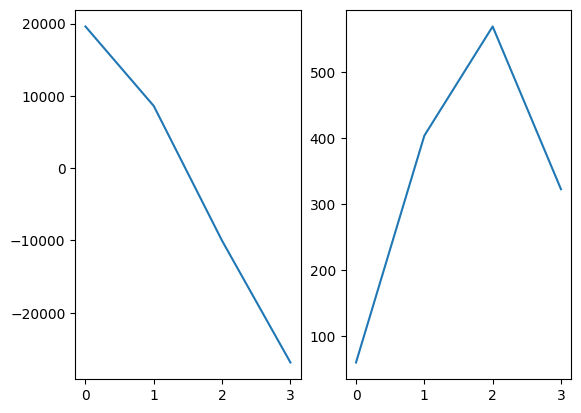

In [5]:
fig, ax = plt.subplots(1,2)
ax[0].plot(fq_1_measured)
ax[1].plot(fq_2_measured)

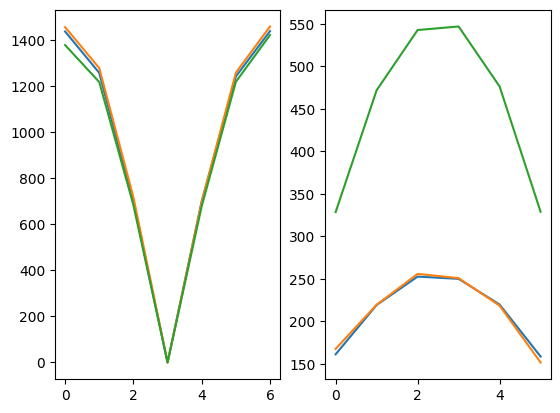

In [6]:
fig, ax = plt.subplots(1,2)
ax[0].plot(f_ner1_measured.T)
ax[1].plot(f_ner2_measured.T)

In [7]:
B0 = np.mean(nmr[0])/GAMMA_NUCLEAR

def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta)
    return H_zeeman + H_q

# R-tensor (Si, (110) orientation): maps AC field [Ex, Ey, Ez] → EFG Voigt vector
_R_tensor = get_R_tensor()   # (6, 3)

def _drive_in_eigenbasis(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z):
    """Drive Hamiltonian (from AC field E_ac) in the energy eigenbasis of H_ion."""
    E_ac       = np.array([E_x, E_y, E_z])
    EFG_tensor = voigt_to_tensor(_R_tensor @ E_ac)
    H_drive    = quadrupole_hamiltonian_from_Vab(I_SPIN, EFG_tensor, Q_N).full()
    H_ion      = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    _, evecs   = H_ion.eigenstates()
    U          = np.column_stack([v.full().flatten() for v in evecs])
    return U.conj().T @ H_drive @ U

def ner1(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z), 1))

def ner2(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, scale=1.0):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, scale*E_x, scale*E_y, scale*E_z), 2))

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz).eigenstates()[0]
    return np.flip(np.diff(evals)).flatten()


In [8]:
B0

np.float64(0.942598120978121)

In [9]:

def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    return np.vstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
    ])

params = Parameters()
params.add('Vxx', value=-4, min=-5,  max=5)
params.add('Vyy', value=1,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)
# params.add('scale', value=0, min=0, max=0.1)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.595       -5        5  0.05225     True     None     None
Vxy     1.319      -20       20  0.05469     True     None     None
Vxz    0.3788       -5       20  0.04196     True     None     None
Vyy    -0.966       -5        5  0.06512     True     None     None
Vyz     1.355       -5       20  0.04369     True     None     None
Vzz    -1.629     -inf      inf  0.02473    False - Vxx - Vyy     None


In [10]:
# def residual(params):
#     p = params.valuesdict()
#     nmr_freqs = nmr_frequencies(**p).flatten()
#     ner1_rabi = ner1(**p).flatten()
#     ner2_rabi = ner2(**p).flatten()
#     fq1 = np.mean(np.diff(nmr_freqs))
#     fq2 = np.mean(np.diff(np.diff(nmr_freqs)))
#     res = np.hstack([
#         np.abs(fq_1_measured - fq1)**2 / np.abs(np.max(fq_1_measured))**2,
#         np.abs(fq_2_measured - fq2)**2 / np.abs(np.max(fq_2_measured))**2,
#         np.abs(f_ner1_measured - ner1_rabi)**2 / np.abs(np.max(f_ner1_measured))**2,
#         np.abs(f_ner2_measured - ner2_rabi)**2 / np.abs(np.max(f_ner2_measured))**2,
#     ])
#     return res



In [11]:
result

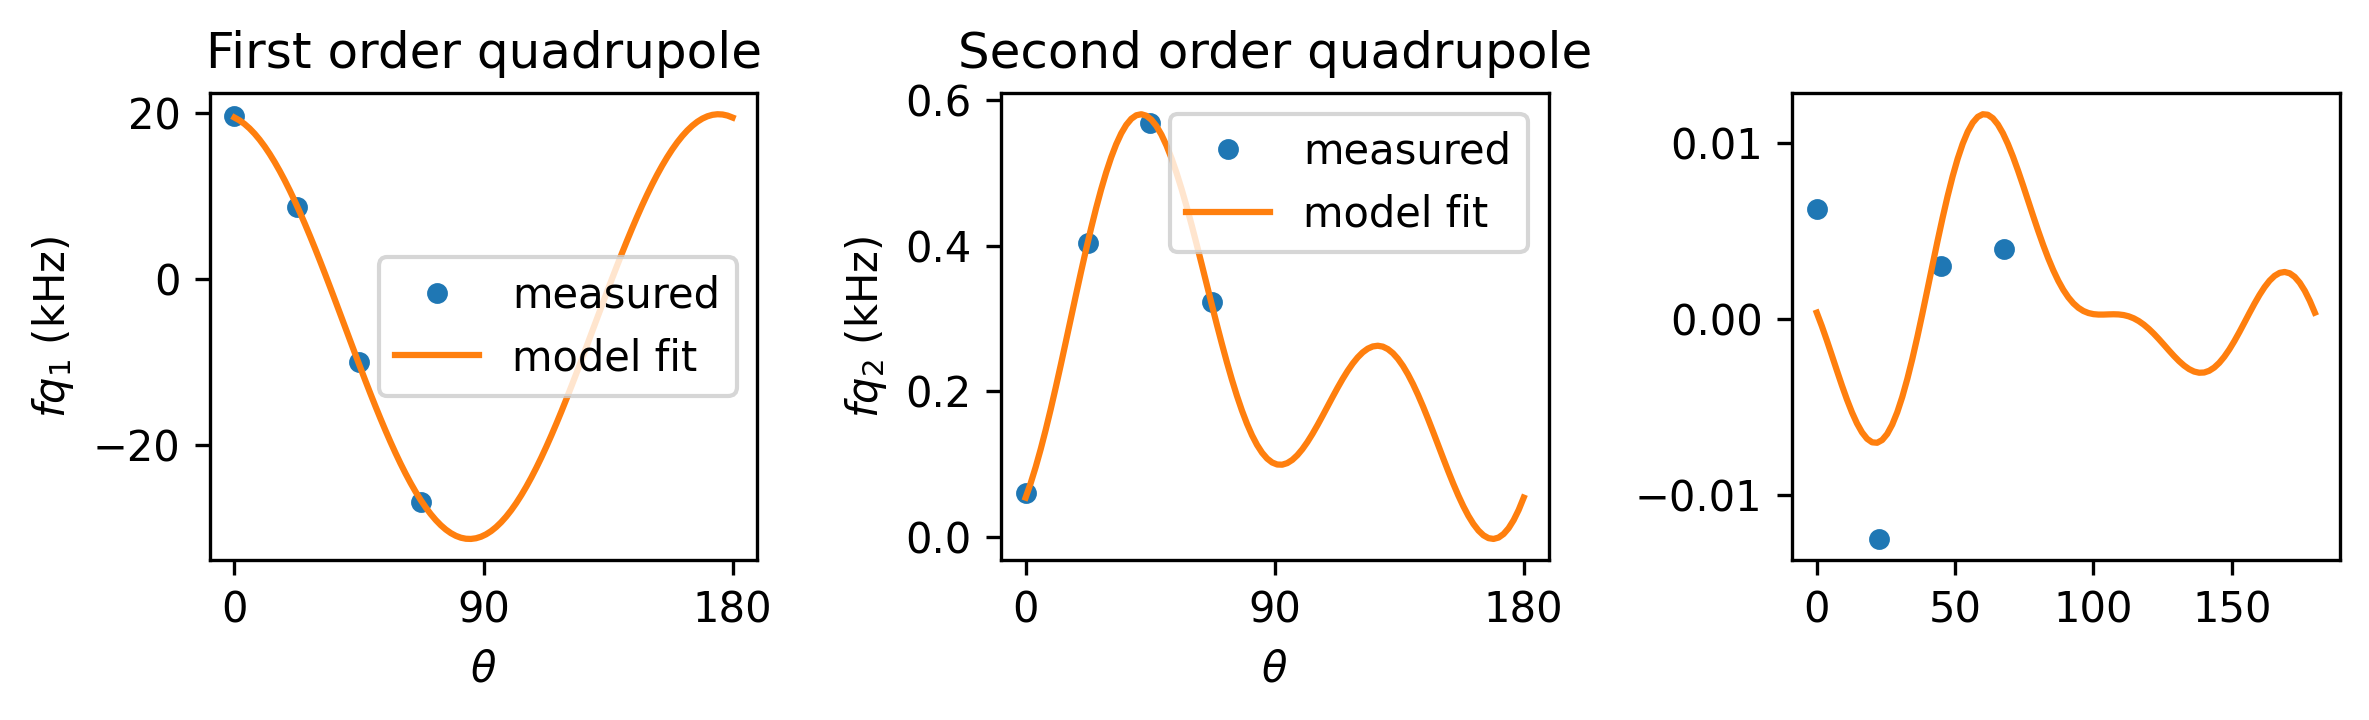

In [12]:
p = result.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)
fq1_arr = np.zeros(len(thetas_fit))
fq2_arr = np.zeros(len(thetas_fit))
fq3_arr = np.zeros(len(thetas_fit))
for t, theta in enumerate(thetas_fit):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    fq3_arr[t] = np.mean(np.diff(np.diff(np.diff(np.diff(evals)))))

fig, ax = plt.subplots(1, 3, figsize=(8, 2.5), dpi=300)
ax[0].plot(thetas / np.pi * 180, fq_1_measured * 1e-3, '.', markersize=8, label='measured')
ax[0].plot(thetas_fit / np.pi * 180, fq1_arr * 1e-3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq_2_measured * 1e-3, '.', markersize=8, label='measured')
ax[1].plot(thetas_fit / np.pi * 180, fq2_arr * 1e-3, label='model fit')
ax[2].plot(thetas / np.pi * 180, fq_3_measured * 1e-3, '.', markersize=8, label='measured')
ax[2].plot(thetas_fit / np.pi * 180, fq3_arr * 1e-3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

In [13]:
p = result.params.valuesdict()
ner1_arr = np.zeros((len(thetas), 7))
ner2_arr = np.zeros((len(thetas), 6))
for t, theta in enumerate(thetas):
    ner1_arr[t] = ner1(theta, **p, E_x=100000, E_y=100000, E_z=100000)
    ner2_arr[t] = ner2(theta, **p, E_x=40000, E_y=40000, E_z=100000)

In [14]:
ner1_arr

array([[529.2821578 , 464.65325177, 261.81545835,   3.26595972,
        260.61206398, 469.78483709, 541.10393174],
       [479.57450809, 415.92246088, 230.0951891 ,  12.07616683,
        235.27595756, 416.14940398, 474.1258714 ],
       [539.95576804, 465.68968815, 254.34849356,  12.83559258,
        268.32460309, 468.81247406, 530.40821986],
       [475.36848524, 411.77290434, 225.9586377 ,   7.80244938,
        239.38299117, 420.49488279, 477.8409106 ]])

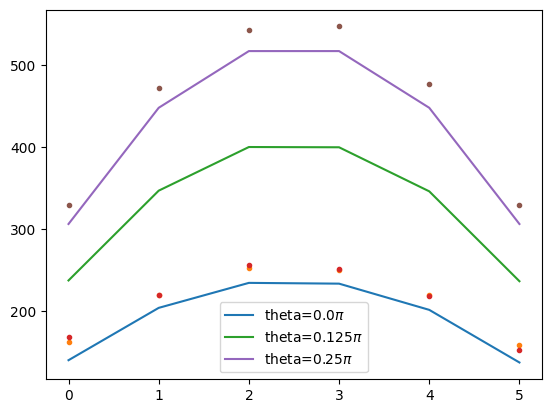

In [15]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner2_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner2_measured[t], '.')
plt.legend()

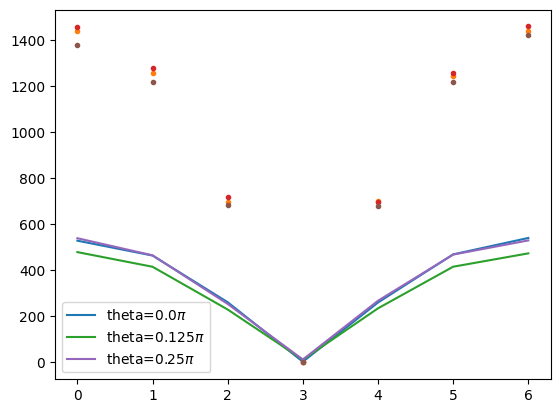

In [16]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner1_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner1_measured[t], '.')
plt.legend()

## Combined fit: fq_1, fq_2, and NER1 Rabi frequencies

In [17]:

_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p)
        ner2_arr[t]  = ner2(theta, **p)
    return np.hstack([
        (fq1_arr  - fq_1_measured)                    / np.max(np.abs(fq_1_measured)),
        (fq2_arr  - fq_2_measured)                    / np.max(np.abs(fq_2_measured)),
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# With the psyduck R-tensor (Si, 110 orientation):
#   Ez drives NER1 ({Iy,Iz})  →  scale_z ~ 270000 (estimated from NER1 outer transition ~1438 Hz)
#   Ey drives NER2 (Ix²-Iz²) →  scale_y ~ 52000  (estimated from NER2 outer transition ~161  Hz)
#   Ex drives NER2 ({Ix,Iy})  →  scale_x free, start small
params_full = result.params.copy()
params_full.add('E_x', value=0,       vary=False)
params_full.add('E_y', value=52000,   min=-1e7, max=1e7)
params_full.add('E_z', value=270000,  min=-1e7, max=1e7)

result_full = minimize(residual_full, params_full, method='leastsq')
result_full.params.pretty_print()


ValueError: operands could not be broadcast together with shapes (4,7) (3,7) 

In [200]:
result_full

In [297]:

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_full)
    ner2_fit[t]  = ner2(th, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(10, 10), dpi=150)

axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=f'$m={i-3}\\to{i-2}$')
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=7, ncol=2)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=f'$m={i-3}\\to{i-1}$')
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
axes[3].legend(fontsize=7, ncol=2)

for ax in axes:
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_xticks([0, 45, 90, 135, 180])
plt.tight_layout()


TypeError: ionized_hamiltonian() missing 6 required positional arguments: 'Vxx', 'Vyy', 'Vzz', 'Vxy', 'Vyz', and 'Vxz'

## just fit the scales, keep the tensor

In [18]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas)-1)
    fq2_arr   = np.zeros(len(thetas)-1)
    ner1_arr  = np.zeros((len(thetas)-1, 7))
    ner2_arr  = np.zeros((len(thetas)-1, 6))
    for t, theta in enumerate(thetas[:-1]):
        evals = ionized_hamiltonian(theta, **p_tensor, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p_tensor, **p)
        ner2_arr[t]  = ner2(theta, **p_tensor, **p)
    return np.hstack([
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('E_x', value=20,   min=-1e7, max=1e7)
params.add('E_y', value=1,  min=-1e7, max=1e7)
params.add('E_z', value=1,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)


result_full = minimize(residual_full, params, method='leastsq')
result_full


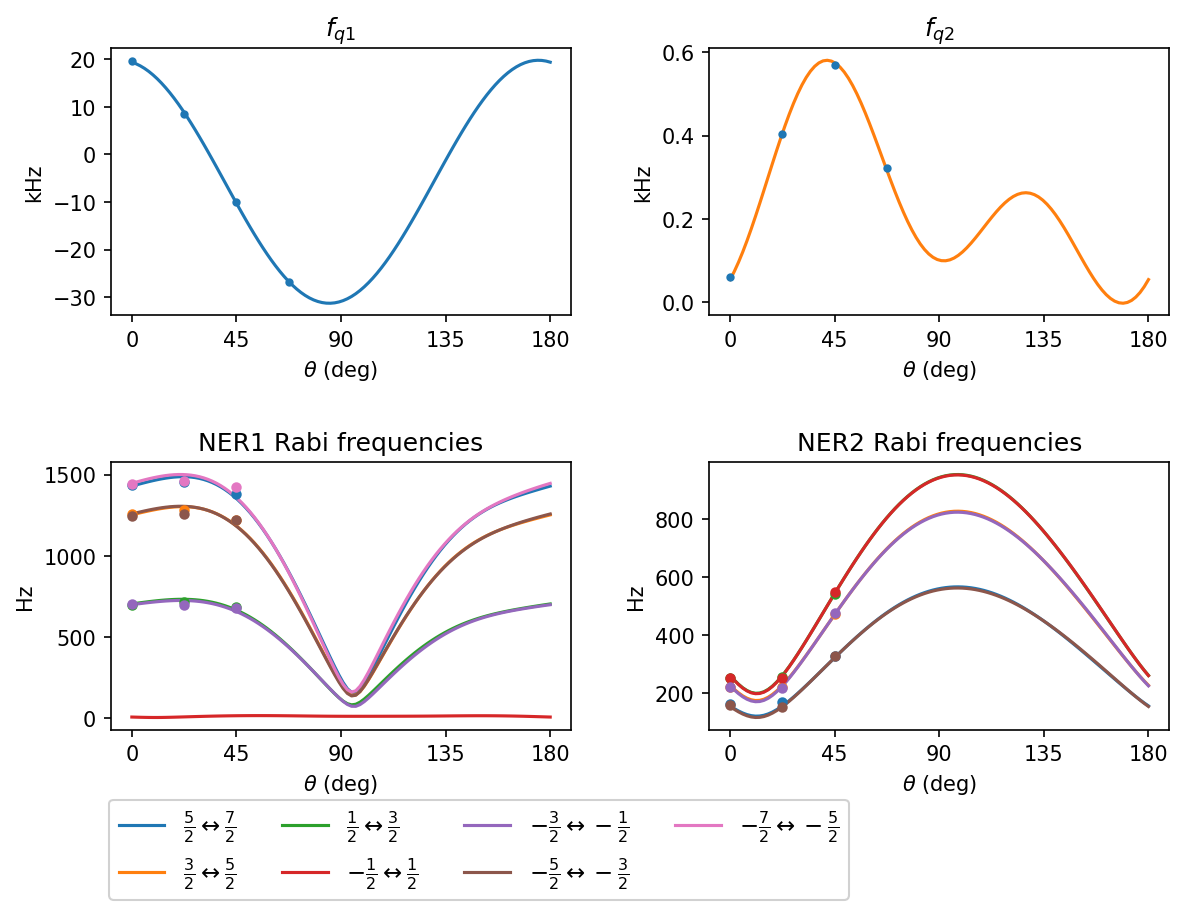

In [19]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_tensor, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_tensor, **p_full)
    ner2_fit[t]  = ner2(th, **p_tensor, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[:-1][mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=11, ncol=4, loc='upper center',
               bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg[:-1], f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)


# visualize the tensor

In [20]:
Vxx = p_tensor['Vxx']
Vyy = p_tensor['Vyy']
Vzz = p_tensor['Vzz']
Vxy = p_tensor['Vxy']
Vyz = p_tensor['Vyz']
Vxz = p_tensor['Vxz']
V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19

spin_dim = 7/2
Ix = qt.jmat(spin_dim,'x')
Iy = qt.jmat(spin_dim,'y')
Iz = qt.jmat(spin_dim,'z')
Iz2 = Iz*Iz
Ix2 = Ix*Ix

def calculate_H_quad(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    V_ab = np.array([[Vxx, -Vxy, -Vxz], [Vxy, Vyy, -Vyz], [-Vxz, -Vyz, Vzz]])*1e19
    I_vec = [Ix, Iy, Iz]
    q_n = -0.69e-28
    e = 1.6e-19
    h = 6.626e-34
    I = 7/2
    Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

    H_quad = 0
    for alpha in [0, 1, 2]:
        for beta in [0, 1, 2]:
            H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]

    H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz
    return H_quad

def calculate_ionized_H(theta, phi, V_ab):
    I_vec = [Ix, Iy, Iz]
    q_n = -0.69e-28
    e = 1.6e-19
    h = 6.626e-34
    I = 7/2
    Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

    H_quad = 0
    for alpha in [0, 1, 2]:
        for beta in [0, 1, 2]:
            H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]

    H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz

    H = - 1 * 5.55 * (Iz * np.cos(theta) + np.sin(theta) * np.cos(phi) * Ix + np.sin(theta) * np.sin(phi) * Iy) + H_quad
    return H

def calculate_H_eigenvalues(theta, phi, V_ab):
    H = calculate_ionized_H(theta, phi, V_ab)
    (eigenvalues_ionized, eigenstates_ionized) = H.eigenstates()
    return eigenvalues_ionized

def calculate_fq1(eigenvalues):
    return np.mean(np.diff(np.diff(eigenvalues)))

def calculate_fq2(eigenvalues):
    return np.mean(np.diff(np.diff(np.diff(eigenvalues))))

thetas_fit = np.linspace(0, np.pi, 50)
phis_fit = np.linspace(0, 2*np.pi, 100)
fq1 = np.zeros((len(thetas_fit), len(phis_fit)))
fq2 = np.zeros((len(thetas_fit), len(phis_fit)))
for i, theta in enumerate(thetas_fit):
    for j, phi in enumerate(phis_fit):
        eigenvalues = calculate_H_eigenvalues(theta, phi, V_ab)
        fq1[i, j] = calculate_fq1(eigenvalues)
        fq2[i, j] = calculate_fq2(eigenvalues)

In [21]:
thetas.shape

(4,)

Text(0.5, 0.5, 'Y')

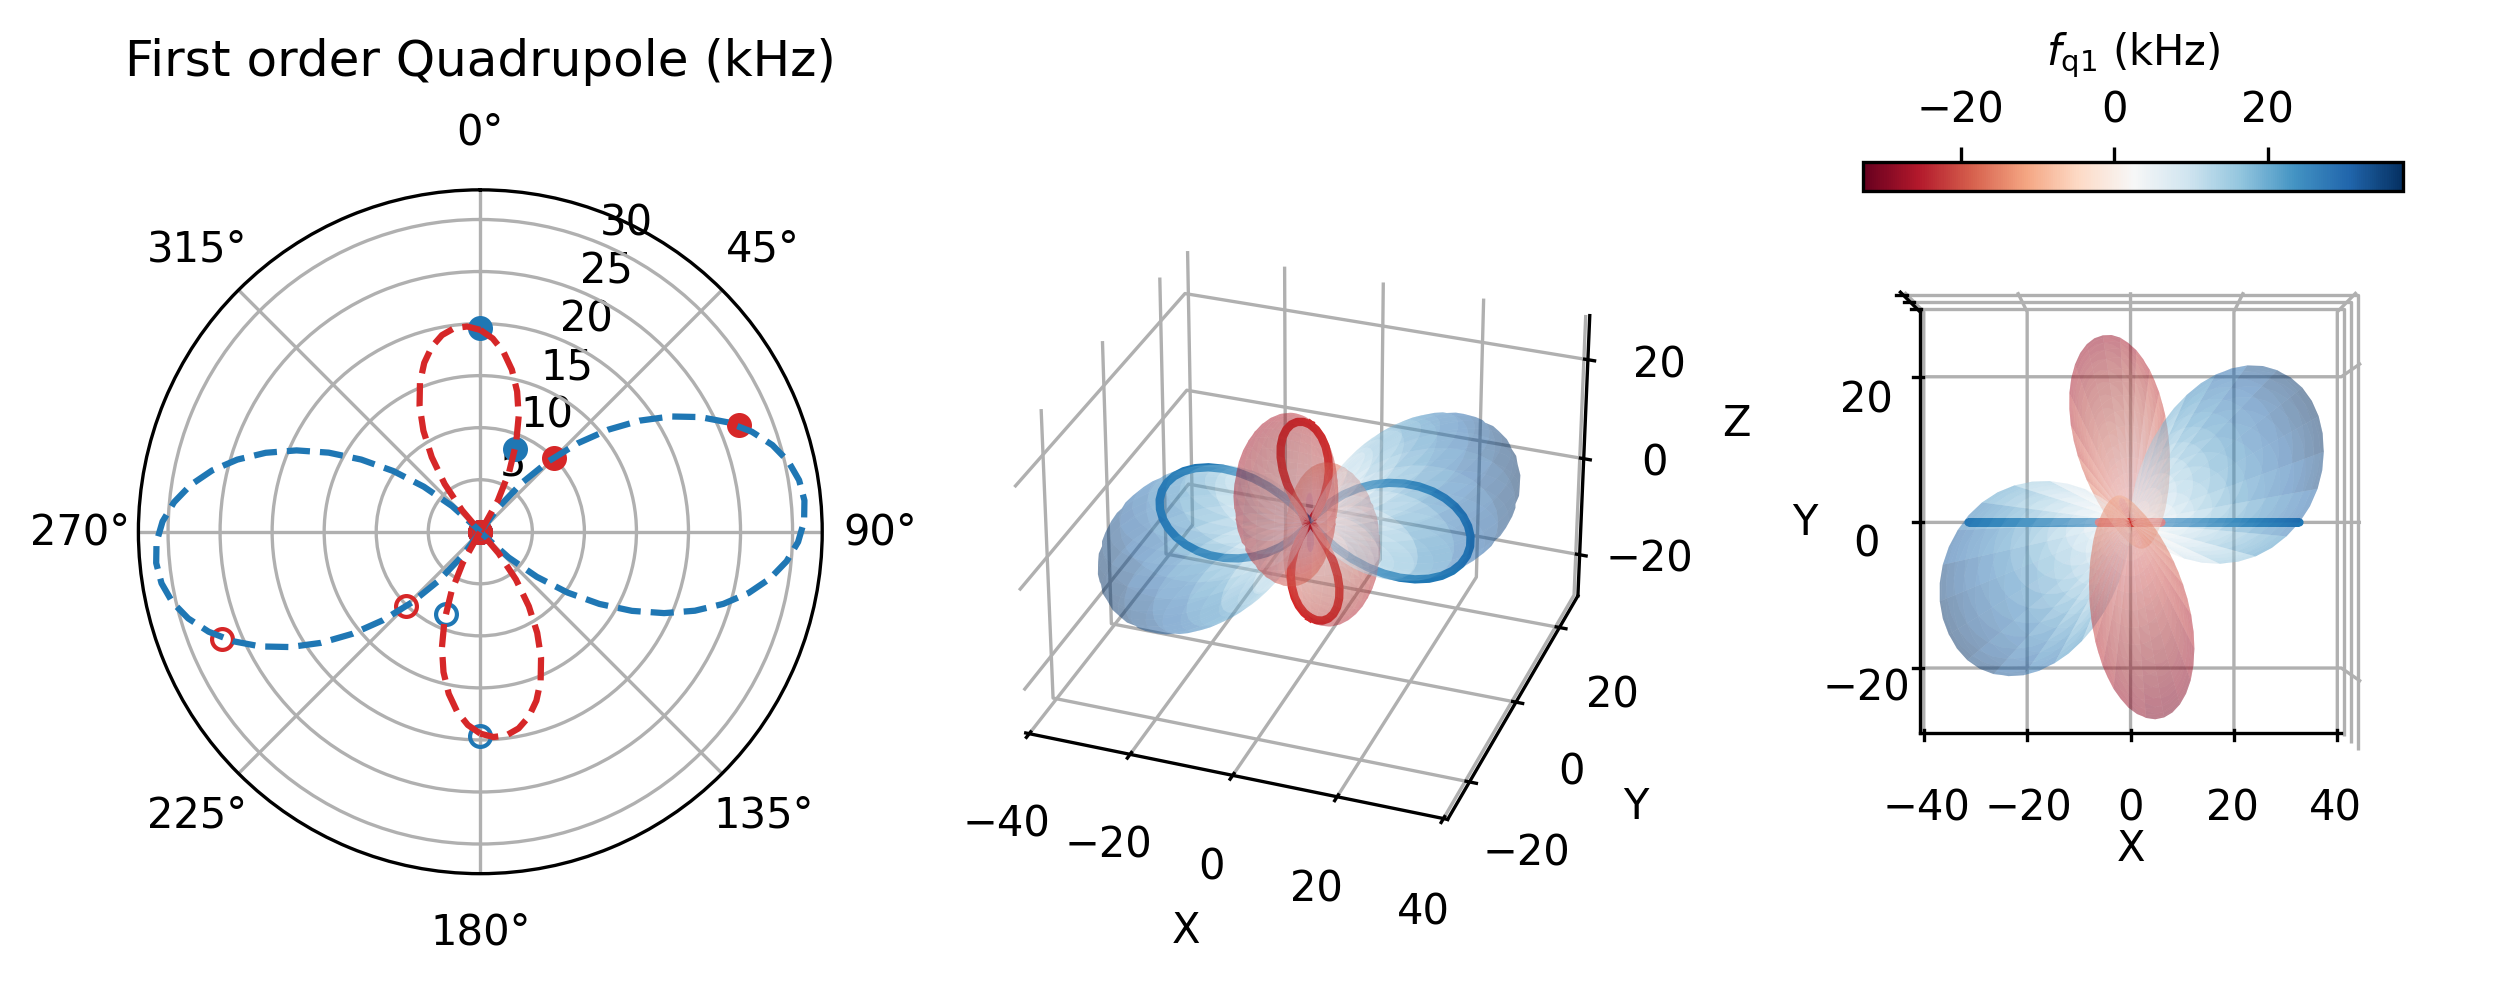

In [25]:
from matplotlib import cm
from matplotlib.colors import Normalize

# TH, PH should match fq1 shape: (len(thetas), len(phis))
TH, PH = np.meshgrid(thetas_fit, phis_fit, indexing='ij')  # indexing='ij' -> TH.shape == fq1.shape

cmap = plt.get_cmap('RdBu')

r = -fq1*1e3  # can contain negative values; see note below
# Cartesian coordinates
X = np.abs(r) * np.sin(TH) * np.cos(PH)
Y = np.abs(r) * np.sin(TH) * np.sin(PH)
Z = np.abs(r) * np.cos(TH)

fig = plt.figure(figsize=(10,3.2), dpi=300)
ax0 = fig.add_subplot(131, projection='polar')
ax0.set_theta_offset(np.pi/2)
ax0.set_theta_direction(-1)
ax1 = fig.add_subplot(132, projection='3d')
ax2 = fig.add_subplot(133, projection='3d')

markersize=10

r_polar = 1e-3*fq_1_measured
r_fit = -fq1[:, 0]*1e3

r_pos = r_polar.copy()
r_pos[r_polar<0] = 0
r_neg = r_polar.copy()
r_neg[r_polar>0] = 0
theta_pos = thetas.copy()
theta_pos[r_polar<0] = 0
theta_neg = thetas.copy()
theta_neg[r_polar>0] = 0

r_fit_pos = r_fit.copy()
r_fit_pos[r_fit<0] = 0
r_fit_neg = r_fit.copy()
r_fit_neg[r_fit>0] = 0
theta_fit_pos = thetas_fit.copy()
theta_fit_pos[r_fit<0] = 0
theta_fit_neg = thetas_fit.copy()
theta_fit_neg[r_fit>0] = 0

ax0.plot(theta_pos, np.abs(r_pos), color='tab:blue', marker='.', ls='None', markersize=markersize)
ax0.plot(theta_neg, np.abs(r_neg), color='tab:red', marker='.', ls='None', markersize=markersize)
ax0.plot(theta_pos+np.pi, np.abs(r_pos), color='tab:blue', ls='None', markersize=markersize, marker='.', markerfacecolor='None')
ax0.plot(theta_neg+np.pi, np.abs(r_neg), color='tab:red', ls='None', markersize=markersize, marker='.', markerfacecolor='None')
ax0.plot(np.linspace(0, 2*np.pi, 100), np.zeros(100), marker='None', color='k')

# Add r_fit to the plot
ax0.plot(theta_fit_pos, np.abs(r_fit_pos), color='tab:blue', linestyle='--')
ax0.plot(theta_fit_neg, np.abs(r_fit_neg), color='tab:red', linestyle='--')
ax0.plot(theta_fit_pos+np.pi, np.abs(r_fit_pos), color='tab:blue', linestyle='--')
ax0.plot(theta_fit_neg+np.pi, np.abs(r_fit_neg), color='tab:red', linestyle='--')

ax0.grid(True)
ax0.set_title("First order Quadrupole (kHz)", va='bottom')

# color by r (or use np.sign(r) to separate sign)
norm = Normalize(vmin=np.nanmin(r), vmax=np.nanmax(r))
facecolors = cmap(norm(r))  # shape (nrows, ncols, 4)

# set surface transparency (0.0 transparent ... 1.0 opaque)
alpha_surf = 0.3
facecolors[..., 3] = facecolors[..., 3] * alpha_surf

# surface plot (transparent)
surf = ax1.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    linewidth=0, antialiased=True, shade=False
)

# surface plot (transparent)
surf2 = ax2.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    linewidth=0, antialiased=True, shade=False
)

# draw phi cross-sections AFTER the surface so they appear on top

plane_alpha = 1

# colorbar (use the original scalar mappable)
m = cm.ScalarMappable(norm=norm, cmap=cmap)
m.set_array(r)
# place a horizontal colorbar above the figure
cax = fig.add_axes([0.7, 0.85, 0.18, 0.03])  # [left, bottom, width, height] in figure coords
cb = fig.colorbar(m, cax=cax, orientation='horizontal')
cb.set_label(r'$f_{\rm q1}$ (kHz)', labelpad=6)
# move label and ticks to the top of the colorbar
cb.ax.xaxis.set_label_position('top')
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_tick_params(pad=4)

# Draw phi cross-sections that correspond to the polar trace (e.g. phi=0 and phi=pi)
phi_vals = [0.0, np.pi]
phi_labels = ['phi=0', 'phi=pi']
colors = ['tab:blue', 'tab:red']  # match polar positive/negative colors

# ensure thetas and phis are the same arrays used to build fq1

for k, phi_val in enumerate(phi_vals):
    # find nearest phi index
    j = int(np.argmin(np.abs(phis_fit - phi_val)))
    r_slice = -fq1[:, j] * 1e3

    pos_mask = r_slice >= 0
    neg_mask = r_slice < 0

    # coordinates for positive part
    if pos_mask.any():
        th_pos = thetas_fit[pos_mask]
        r_pos = np.abs(r_slice[pos_mask])
        Xp = r_pos * np.sin(th_pos) * np.cos(phi_val)
        Yp = r_pos * np.sin(th_pos) * np.sin(phi_val)
        Zp = r_pos * np.cos(th_pos)
        ax1.plot(Xp, Yp, Zp, color='tab:blue', lw=2, label=f'{phi_labels[k]} (pos)')
        ax2.plot(Xp, Yp, Zp, color='tab:blue', lw=2)

        # projection onto X-Z plane (Y=0)
        # ax1.plot(Xp, np.zeros_like(Xp), Zp, color='gray', ls='--', lw=1)

    # coordinates for negative part
    if neg_mask.any():
        th_neg = thetas_fit[neg_mask]
        r_neg = np.abs(r_slice[neg_mask])
        Xn = r_neg * np.sin(th_neg) * np.cos(phi_val)
        Yn = r_neg * np.sin(th_neg) * np.sin(phi_val)
        Zn = r_neg * np.cos(th_neg)
        ax1.plot(Xn, Yn, Zn, color='tab:red', lw=2, label=f'{phi_labels[k]} (neg)')
        ax2.plot(Xn, Yn, Zn, color='tab:red', lw=2)

        # ax1.plot(Xn, np.zeros_like(Xn), Zn, color='gray', ls='--', lw=1)

        # colorbar
m = cm.ScalarMappable(norm=norm, cmap=cmap)
m.set_array(r)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# view angle
ax1.view_init(elev=30, azim=-70)
fig.patch.set_facecolor('white')
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# view angle
ax2.view_init(elev=90, azim=-90)
fig.patch.set_facecolor('white')
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

plt.setp(ax2.get_zticklabels(), visible=False)

ax1.set_facecolor('white')
ax2.set_facecolor('white')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')

# plt.savefig(r'raw_figs/first_order_quadrupole_3d_plot.png', dpi=900)


Text(0.5, 0.5, 'Y')

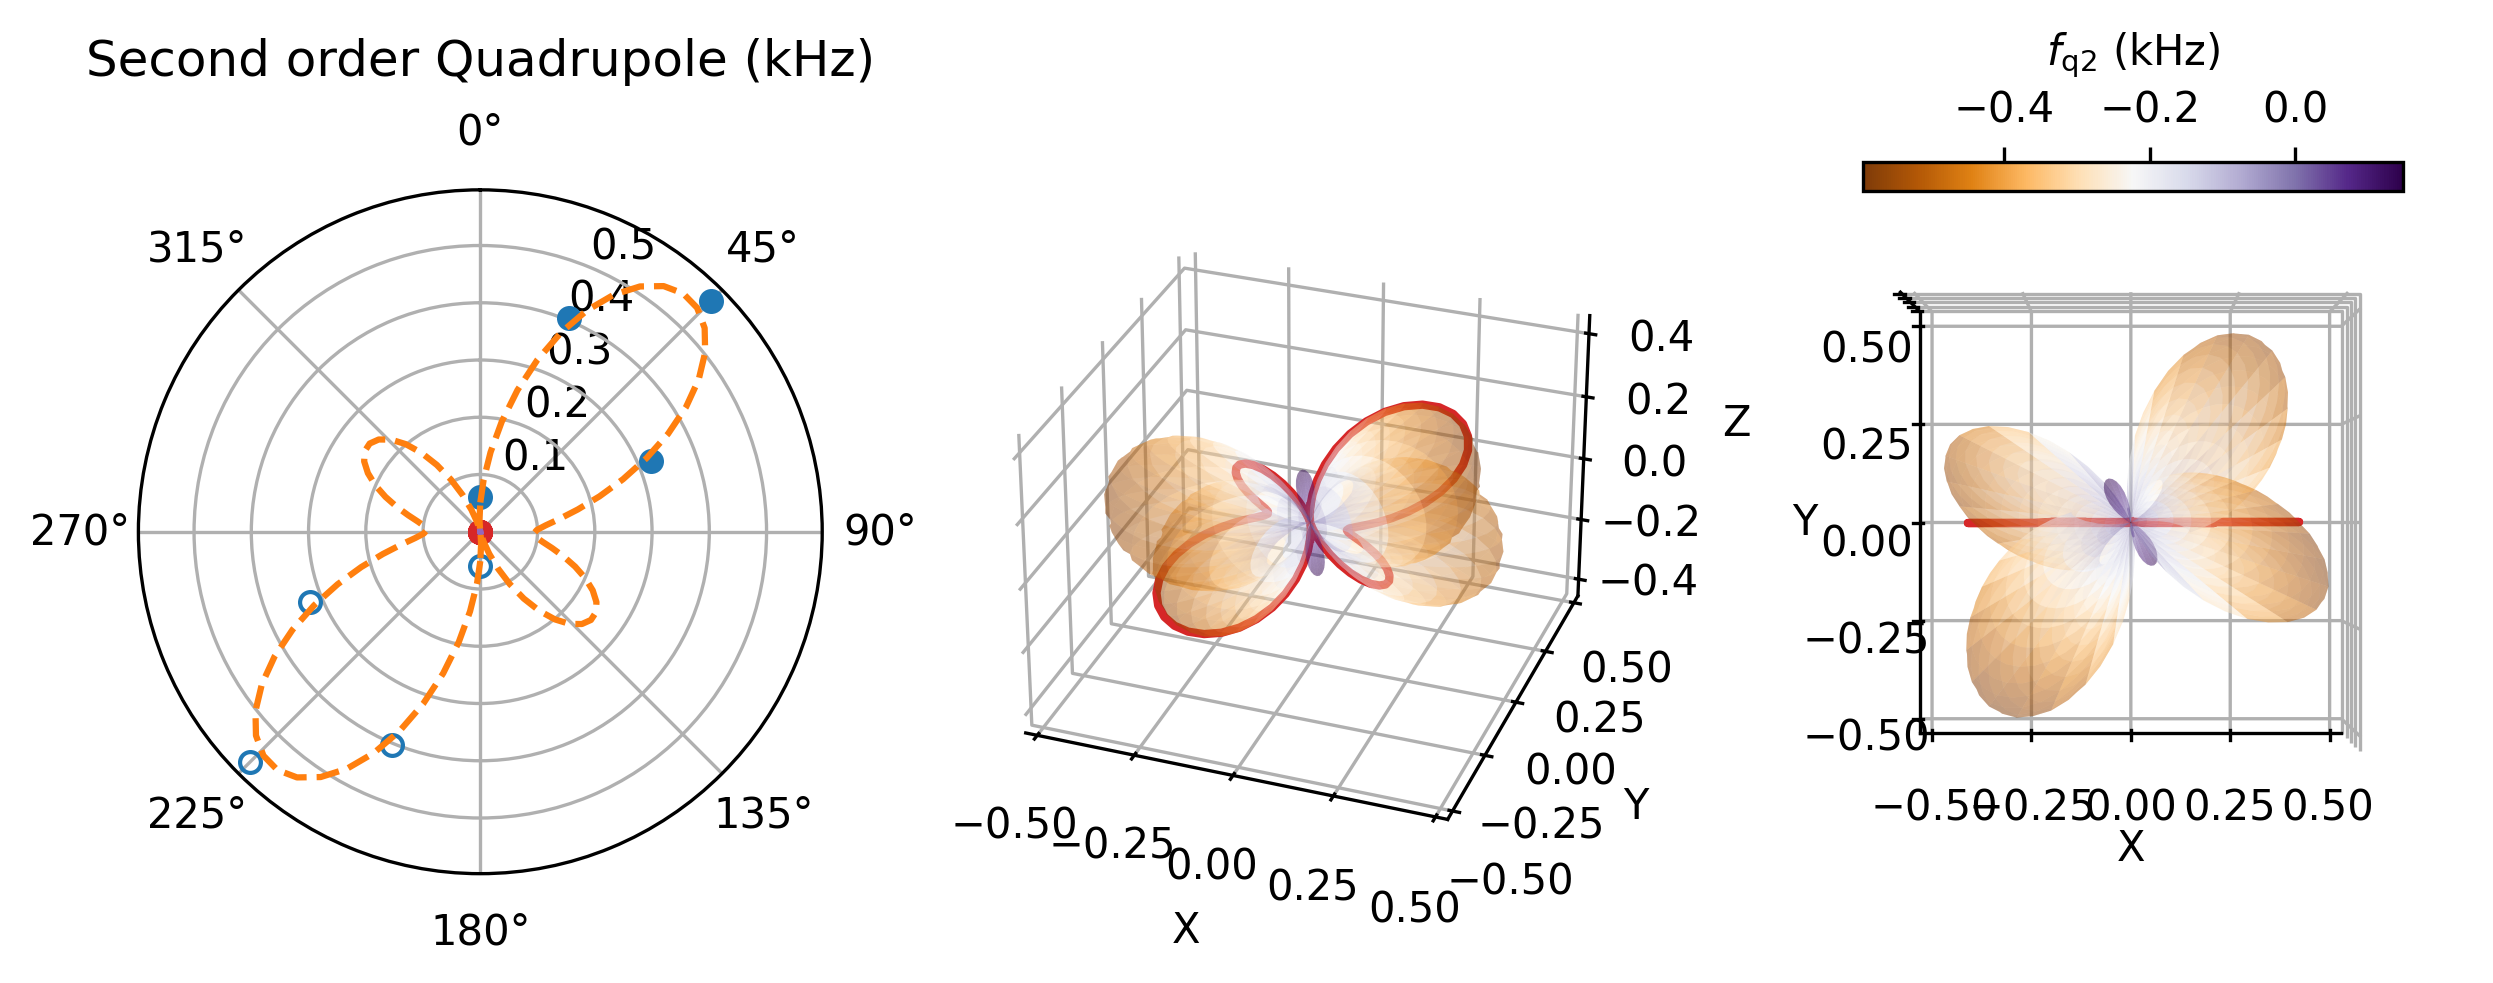

In [30]:
from matplotlib import cm
from matplotlib.colors import Normalize

# TH, PH should match fq1 shape: (len(thetas), len(phis))
TH, PH = np.meshgrid(thetas_fit, phis_fit, indexing='ij')  # indexing='ij' -> TH.shape == fq1.shape

cmap = plt.get_cmap('PuOr')

r = -fq2*1e3  # can contain negative values; see note below
# Cartesian coordinates
X = np.abs(r) * np.sin(TH) * np.cos(PH)
Y = np.abs(r) * np.sin(TH) * np.sin(PH)
Z = np.abs(r) * np.cos(TH)

fig = plt.figure(figsize=(10,3.2), dpi=300)
ax0 = fig.add_subplot(131, projection='polar')
ax0.set_theta_offset(np.pi/2)
ax0.set_theta_direction(-1)
ax1 = fig.add_subplot(132, projection='3d')
ax2 = fig.add_subplot(133, projection='3d')

markersize=10

r_polar = 1e-3*fq_2_measured
r_fit = -fq2[:, 0]*1e3

r_pos = r_polar.copy()
r_pos[r_polar<0] = 0
r_neg = r_polar.copy()
r_neg[r_polar>0] = 0
theta_pos = thetas.copy()
theta_pos[r_polar<0] = 0
theta_neg = thetas.copy()
theta_neg[r_polar>0] = 0

r_fit_pos = r_fit.copy()
r_fit_pos[r_fit<0] = 0
r_fit_neg = r_fit.copy()
r_fit_neg[r_fit>0] = 0
theta_fit_pos = thetas_fit.copy()
theta_fit_pos[r_fit<0] = 0
theta_fit_neg = thetas_fit.copy()
theta_fit_neg[r_fit>0] = 0

ax0.plot(theta_pos, np.abs(r_pos), color='tab:blue', marker='.', ls='None', markersize=markersize)
ax0.plot(theta_neg, np.abs(r_neg), color='tab:red', marker='.', ls='None', markersize=markersize)
ax0.plot(theta_pos+np.pi, np.abs(r_pos), color='tab:blue', ls='None', markersize=markersize, marker='.', markerfacecolor='None')
ax0.plot(theta_neg+np.pi, np.abs(r_neg), color='tab:red', ls='None', markersize=markersize, marker='.', markerfacecolor='None')
ax0.plot(np.linspace(0, 2*np.pi, 100), np.zeros(100), marker='None', color='k')

# Add r_fit to the plot
ax0.plot(theta_fit_pos, np.abs(r_fit_pos), color='tab:purple', linestyle='--')
ax0.plot(theta_fit_neg, np.abs(r_fit_neg), color='tab:orange', linestyle='--')
ax0.plot(theta_fit_pos+np.pi, np.abs(r_fit_pos), color='tab:purple', linestyle='--')
ax0.plot(theta_fit_neg+np.pi, np.abs(r_fit_neg), color='tab:orange', linestyle='--')

ax0.grid(True)
ax0.set_title("Second order Quadrupole (kHz)", va='bottom')

# color by r (or use np.sign(r) to separate sign)
norm = Normalize(vmin=np.nanmin(r), vmax=np.nanmax(r))
facecolors = cmap(norm(r))  # shape (nrows, ncols, 4)

# set surface transparency (0.0 transparent ... 1.0 opaque)
alpha_surf = 0.3
facecolors[..., 3] = facecolors[..., 3] * alpha_surf

# surface plot (transparent)
surf = ax1.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    linewidth=0, antialiased=True, shade=False
)

# surface plot (transparent)
surf2 = ax2.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    linewidth=0, antialiased=True, shade=False
)

# draw phi cross-sections AFTER the surface so they appear on top

plane_alpha = 1

# colorbar (use the original scalar mappable)
m = cm.ScalarMappable(norm=norm, cmap=cmap)
m.set_array(r)
# place a horizontal colorbar above the figure
cax = fig.add_axes([0.7, 0.85, 0.18, 0.03])  # [left, bottom, width, height] in figure coords
cb = fig.colorbar(m, cax=cax, orientation='horizontal')
cb.set_label(r'$f_{\rm q2}$ (kHz)', labelpad=6)
# move label and ticks to the top of the colorbar
cb.ax.xaxis.set_label_position('top')
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_tick_params(pad=4)

# Draw phi cross-sections that correspond to the polar trace (e.g. phi=0 and phi=pi)
phi_vals = [0.0, np.pi]
phi_labels = ['phi=0', 'phi=pi']
colors = ['tab:blue', 'tab:red']  # match polar positive/negative colors

# ensure thetas and phis are the same arrays used to build fq1

for k, phi_val in enumerate(phi_vals):
    # find nearest phi index
    j = int(np.argmin(np.abs(phis_fit - phi_val)))
    r_slice = -fq2[:, j] * 1e3

    pos_mask = r_slice >= 0
    neg_mask = r_slice < 0

    # coordinates for positive part
    if pos_mask.any():
        th_pos = thetas_fit[pos_mask]
        r_pos = np.abs(r_slice[pos_mask])
        Xp = r_pos * np.sin(th_pos) * np.cos(phi_val)
        Yp = r_pos * np.sin(th_pos) * np.sin(phi_val)
        Zp = r_pos * np.cos(th_pos)
        ax1.plot(Xp, Yp, Zp, color='tab:blue', lw=2, label=f'{phi_labels[k]} (pos)')
        ax2.plot(Xp, Yp, Zp, color='tab:blue', lw=2)

        # projection onto X-Z plane (Y=0)
        # ax1.plot(Xp, np.zeros_like(Xp), Zp, color='gray', ls='--', lw=1)

    # coordinates for negative part
    if neg_mask.any():
        th_neg = thetas_fit[neg_mask]
        r_neg = np.abs(r_slice[neg_mask])
        Xn = r_neg * np.sin(th_neg) * np.cos(phi_val)
        Yn = r_neg * np.sin(th_neg) * np.sin(phi_val)
        Zn = r_neg * np.cos(th_neg)
        ax1.plot(Xn, Yn, Zn, color='tab:red', lw=2, label=f'{phi_labels[k]} (neg)')
        ax2.plot(Xn, Yn, Zn, color='tab:red', lw=2)

        # ax1.plot(Xn, np.zeros_like(Xn), Zn, color='gray', ls='--', lw=1)

        # colorbar
m = cm.ScalarMappable(norm=norm, cmap=cmap)
m.set_array(r)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# view angle
ax1.view_init(elev=30, azim=-70)
fig.patch.set_facecolor('white')
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# view angle
ax2.view_init(elev=90, azim=-90)
fig.patch.set_facecolor('white')
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

plt.setp(ax2.get_zticklabels(), visible=False)

ax1.set_facecolor('white')
ax2.set_facecolor('white')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')

# plt.savefig(r'raw_figs/first_order_quadrupole_3d_plot.png', dpi=900)
